In [ ]:
#clear frame

Threshold = 600

FAR ROW (v = 170)
Left  : u = 163 | brightness = 686 | valid = True
Right : u = 325 | brightness = 686 | valid = True
uf = 244.0

NEAR ROW (v = 260)
Left  : u = 114 | brightness = 686 | valid = True
Right : u = 372 | brightness = 686 | valid = True
un = 243.0


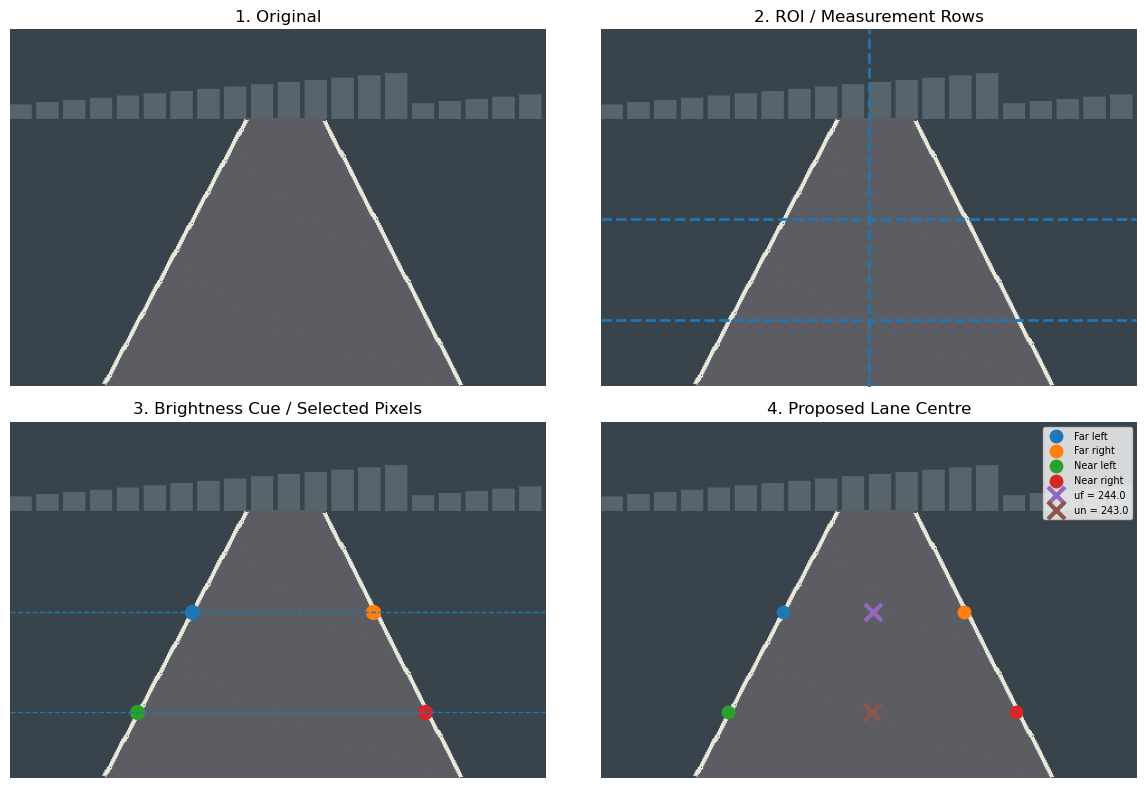

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD IMAGE
# ============================================================

frame = cv2.imread("clear/003.png")

vn = 260
vf = 170
threshold = 600


# ============================================================
# BASELINE DETECTION
# ============================================================

# ---------- FAR ROW ----------
far = np.sum(frame[vf, :, :3], axis=1)

left_far = far[:240]
right_far = far[240:]

lf = np.argmax(left_far)
rf = np.argmax(right_far) + 240

far_left_brightness = left_far[lf]
far_right_brightness = right_far[rf - 240]

far_left_valid = far_left_brightness >= threshold
far_right_valid = far_right_brightness >= threshold

if far_left_valid and far_right_valid:
    uf = (lf + rf) / 2
else:
    uf = None


# ---------- NEAR ROW ----------
near = np.sum(frame[vn, :, :3], axis=1)

left_near = near[:240]
right_near = near[240:]

ln = np.argmax(left_near)
rn = np.argmax(right_near) + 240

near_left_brightness = left_near[ln]
near_right_brightness = right_near[rn - 240]

near_left_valid = near_left_brightness >= threshold
near_right_valid = near_right_brightness >= threshold

if near_left_valid and near_right_valid:
    un = (ln + rn) / 2
else:
    un = None


# ============================================================
# PRINT EXACT DETECTION RESULTS
# ============================================================

print("Threshold =", threshold)

print("\nFAR ROW (v = 170)")
print("Left  : u =", lf,
      "| brightness =", far_left_brightness,
      "| valid =", far_left_valid)

print("Right : u =", rf,
      "| brightness =", far_right_brightness,
      "| valid =", far_right_valid)

print("uf =", uf)


print("\nNEAR ROW (v = 260)")
print("Left  : u =", ln,
      "| brightness =", near_left_brightness,
      "| valid =", near_left_valid)

print("Right : u =", rn,
      "| brightness =", near_right_brightness,
      "| valid =", near_right_valid)

print("un =", un)


# ============================================================
# PREPARE DISPLAY
# ============================================================

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# ============================================================
# 1. ORIGINAL
# ============================================================

ax = axes[0, 0]

ax.imshow(frame_rgb)
ax.set_title("1. Original")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 2. ROI / MEASUREMENT ROWS
# ============================================================

ax = axes[0, 1]

ax.imshow(frame_rgb)

# Far row
ax.axhline(
    vf,
    linestyle="--",
    linewidth=2,
    label="Far row (v=170)"
)

# Near row
ax.axhline(
    vn,
    linestyle="--",
    linewidth=2,
    label="Near row (v=260)"
)

# Left/right split
ax.axvline(
    240,
    linestyle="--",
    linewidth=2,
    label="u=240 split"
)

ax.set_title("2. ROI / Measurement Rows")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 3. BRIGHTNESS CUE
# ============================================================

ax = axes[1, 0]

# Keep ORIGINAL IMAGE visible
ax.imshow(frame_rgb)

# Draw measurement rows
ax.axhline(vf, linestyle="--", linewidth=1)
ax.axhline(vn, linestyle="--", linewidth=1)

# Plot ONLY valid candidate pixels

if far_left_valid:
    ax.scatter(
        lf, vf,
        s=100,
        marker="o",
        label="Far left candidate"
    )

if far_right_valid:
    ax.scatter(
        rf, vf,
        s=100,
        marker="o",
        label="Far right candidate"
    )

if near_left_valid:
    ax.scatter(
        ln, vn,
        s=100,
        marker="o",
        label="Near left candidate"
    )

if near_right_valid:
    ax.scatter(
        rn, vn,
        s=100,
        marker="o",
        label="Near right candidate"
    )

ax.set_title("3. Brightness Cue / Selected Pixels")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 4. PROPOSED LANE CENTRE
# ============================================================

ax = axes[1, 1]

# Same ORIGINAL IMAGE
ax.imshow(frame_rgb)

# Valid boundary candidates
if far_left_valid:
    ax.scatter(
        lf, vf,
        s=80,
        marker="o",
        label="Far left"
    )

if far_right_valid:
    ax.scatter(
        rf, vf,
        s=80,
        marker="o",
        label="Far right"
    )

if near_left_valid:
    ax.scatter(
        ln, vn,
        s=80,
        marker="o",
        label="Near left"
    )

if near_right_valid:
    ax.scatter(
        rn, vn,
        s=80,
        marker="o",
        label="Near right"
    )

# Calculated centres
if uf is not None:
    ax.scatter(
        uf, vf,
        s=150,
        marker="x",
        linewidths=3,
        label=f"uf = {uf:.1f}"
    )

if un is not None:
    ax.scatter(
        un, vn,
        s=150,
        marker="x",
        linewidths=3,
        label=f"un = {un:.1f}"
    )

ax.set_title("4. Proposed Lane Centre")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.legend(fontsize=7)


# ============================================================
# FINAL DISPLAY
# ============================================================

plt.tight_layout()
plt.show()

Threshold = 600

FAR ROW (v = 170)
Left  : u = 168 | brightness = 686 | valid = True
Right : u = 240 | brightness = 282 | valid = False
uf = None

NEAR ROW (v = 260)
Left  : u = 124 | brightness = 686 | valid = True
Right : u = 382 | brightness = 686 | valid = True
un = 253.0


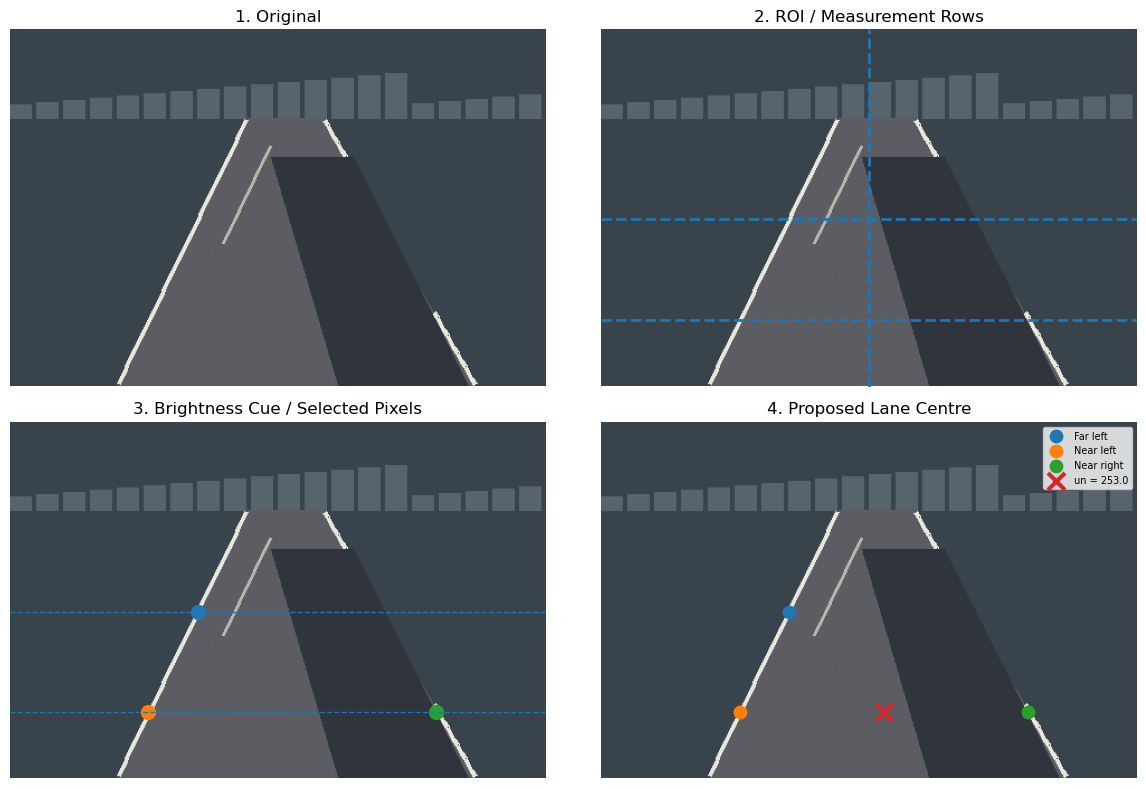

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD IMAGE
# ============================================================

frame = cv2.imread("missing/021.png")

vn = 260
vf = 170
threshold = 600


# ============================================================
# BASELINE DETECTION
# ============================================================

# ---------- FAR ROW ----------
far = np.sum(frame[vf, :, :3], axis=1)

left_far = far[:240]
right_far = far[240:]

lf = np.argmax(left_far)
rf = np.argmax(right_far) + 240

far_left_brightness = left_far[lf]
far_right_brightness = right_far[rf - 240]

far_left_valid = far_left_brightness >= threshold
far_right_valid = far_right_brightness >= threshold

if far_left_valid and far_right_valid:
    uf = (lf + rf) / 2
else:
    uf = None


# ---------- NEAR ROW ----------
near = np.sum(frame[vn, :, :3], axis=1)

left_near = near[:240]
right_near = near[240:]

ln = np.argmax(left_near)
rn = np.argmax(right_near) + 240

near_left_brightness = left_near[ln]
near_right_brightness = right_near[rn - 240]

near_left_valid = near_left_brightness >= threshold
near_right_valid = near_right_brightness >= threshold

if near_left_valid and near_right_valid:
    un = (ln + rn) / 2
else:
    un = None


# ============================================================
# PRINT EXACT DETECTION RESULTS
# ============================================================

print("Threshold =", threshold)

print("\nFAR ROW (v = 170)")
print("Left  : u =", lf,
      "| brightness =", far_left_brightness,
      "| valid =", far_left_valid)

print("Right : u =", rf,
      "| brightness =", far_right_brightness,
      "| valid =", far_right_valid)

print("uf =", uf)


print("\nNEAR ROW (v = 260)")
print("Left  : u =", ln,
      "| brightness =", near_left_brightness,
      "| valid =", near_left_valid)

print("Right : u =", rn,
      "| brightness =", near_right_brightness,
      "| valid =", near_right_valid)

print("un =", un)


# ============================================================
# PREPARE DISPLAY
# ============================================================

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# ============================================================
# 1. ORIGINAL
# ============================================================

ax = axes[0, 0]

ax.imshow(frame_rgb)
ax.set_title("1. Original")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 2. ROI / MEASUREMENT ROWS
# ============================================================

ax = axes[0, 1]

ax.imshow(frame_rgb)

# Far row
ax.axhline(
    vf,
    linestyle="--",
    linewidth=2,
    label="Far row (v=170)"
)

# Near row
ax.axhline(
    vn,
    linestyle="--",
    linewidth=2,
    label="Near row (v=260)"
)

# Left/right split
ax.axvline(
    240,
    linestyle="--",
    linewidth=2,
    label="u=240 split"
)

ax.set_title("2. ROI / Measurement Rows")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 3. BRIGHTNESS CUE
# ============================================================

ax = axes[1, 0]

# Keep ORIGINAL IMAGE visible
ax.imshow(frame_rgb)

# Draw measurement rows
ax.axhline(vf, linestyle="--", linewidth=1)
ax.axhline(vn, linestyle="--", linewidth=1)

# Plot ONLY valid candidate pixels

if far_left_valid:
    ax.scatter(
        lf, vf,
        s=100,
        marker="o",
        label="Far left candidate"
    )

if far_right_valid:
    ax.scatter(
        rf, vf,
        s=100,
        marker="o",
        label="Far right candidate"
    )

if near_left_valid:
    ax.scatter(
        ln, vn,
        s=100,
        marker="o",
        label="Near left candidate"
    )

if near_right_valid:
    ax.scatter(
        rn, vn,
        s=100,
        marker="o",
        label="Near right candidate"
    )

ax.set_title("3. Brightness Cue / Selected Pixels")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")


# ============================================================
# 4. PROPOSED LANE CENTRE
# ============================================================

ax = axes[1, 1]

# Same ORIGINAL IMAGE
ax.imshow(frame_rgb)

# Valid boundary candidates
if far_left_valid:
    ax.scatter(
        lf, vf,
        s=80,
        marker="o",
        label="Far left"
    )

if far_right_valid:
    ax.scatter(
        rf, vf,
        s=80,
        marker="o",
        label="Far right"
    )

if near_left_valid:
    ax.scatter(
        ln, vn,
        s=80,
        marker="o",
        label="Near left"
    )

if near_right_valid:
    ax.scatter(
        rn, vn,
        s=80,
        marker="o",
        label="Near right"
    )

# Calculated centres
if uf is not None:
    ax.scatter(
        uf, vf,
        s=150,
        marker="x",
        linewidths=3,
        label=f"uf = {uf:.1f}"
    )

if un is not None:
    ax.scatter(
        un, vn,
        s=150,
        marker="x",
        linewidths=3,
        label=f"un = {un:.1f}"
    )

ax.set_title("4. Proposed Lane Centre")
ax.set_xlim(0, 480)
ax.set_ylim(320, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.legend(fontsize=7)


# ============================================================
# FINAL DISPLAY
# ============================================================

plt.tight_layout()
plt.show()

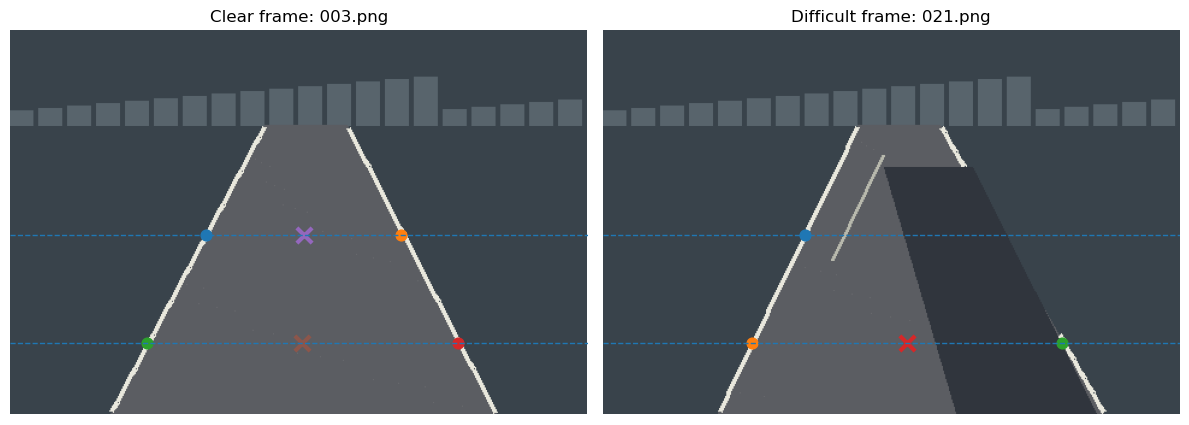

CLEAR FRAME — 003.png
Far  : left = 163 right = 325 uf = 244.0
Near : left = 114 right = 372 un = 243.0

DIFFICULT FRAME — 021.png
Far  : left = 168 right = 240 uf = None
Near : left = 124 right = 382 un = 253.0


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def get_baseline(frame, threshold=500):

    vn = 260
    vf = 170

    # FAR
    far = np.sum(frame[vf, :, :3], axis=1)

    left_far = far[:240]
    right_far = far[240:]

    lf = np.argmax(left_far)
    rf = np.argmax(right_far) + 240

    far_left_brightness = left_far[lf]
    far_right_brightness = right_far[rf - 240]

    far_left_valid = far_left_brightness >= threshold
    far_right_valid = far_right_brightness >= threshold

    uf = (lf + rf) / 2 if far_left_valid and far_right_valid else None

    # NEAR
    near = np.sum(frame[vn, :, :3], axis=1)

    left_near = near[:240]
    right_near = near[240:]

    ln = np.argmax(left_near)
    rn = np.argmax(right_near) + 240

    near_left_brightness = left_near[ln]
    near_right_brightness = right_near[rn - 240]

    near_left_valid = near_left_brightness >= threshold
    near_right_valid = near_right_brightness >= threshold

    un = (ln + rn) / 2 if near_left_valid and near_right_valid else None

    return {
        "lf": lf,
        "rf": rf,
        "ln": ln,
        "rn": rn,
        "uf": uf,
        "un": un,
        "far_left_valid": far_left_valid,
        "far_right_valid": far_right_valid,
        "near_left_valid": near_left_valid,
        "near_right_valid": near_right_valid,
        "far_left_brightness": far_left_brightness,
        "far_right_brightness": far_right_brightness,
        "near_left_brightness": near_left_brightness,
        "near_right_brightness": near_right_brightness
    }


def visualize_frame(ax, frame, title, threshold=500):

    vn = 260
    vf = 170

    result = get_baseline(frame, threshold)

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    # Measurement rows
    ax.axhline(vf, linestyle="--", linewidth=1)
    ax.axhline(vn, linestyle="--", linewidth=1)

    # Valid candidates
    if result["far_left_valid"]:
        ax.scatter(result["lf"], vf, s=60, marker="o")

    if result["far_right_valid"]:
        ax.scatter(result["rf"], vf, s=60, marker="o")

    if result["near_left_valid"]:
        ax.scatter(result["ln"], vn, s=60, marker="o")

    if result["near_right_valid"]:
        ax.scatter(result["rn"], vn, s=60, marker="o")

    # Centres
    if result["uf"] is not None:
        ax.scatter(
            result["uf"], vf,
            s=120, marker="x", linewidths=3
        )

    if result["un"] is not None:
        ax.scatter(
            result["un"], vn,
            s=120, marker="x", linewidths=3
        )

    ax.set_title(title)
    ax.set_xlim(0, 480)
    ax.set_ylim(320, 0)
    ax.set_aspect("equal")
    ax.axis("off")

    return result


# ============================================================
# LOAD BOTH FRAMES
# ============================================================

clear_frame = cv2.imread("clear/003.png")
difficult_frame = cv2.imread("missing/021.png")


# ============================================================
# CREATE COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

clear_result = visualize_frame(
    axes[0],
    clear_frame,
    "Clear frame: 003.png"
)

difficult_result = visualize_frame(
    axes[1],
    difficult_frame,
    "Difficult frame: 021.png"
)

plt.tight_layout()
plt.show()


# ============================================================
# PRINT NUMERICAL COMPARISON
# ============================================================

print("CLEAR FRAME — 003.png")
print("Far  : left =", clear_result["lf"],
      "right =", clear_result["rf"],
      "uf =", clear_result["uf"])
print("Near : left =", clear_result["ln"],
      "right =", clear_result["rn"],
      "un =", clear_result["un"])

print("\nDIFFICULT FRAME — 021.png")
print("Far  : left =", difficult_result["lf"],
      "right =", difficult_result["rf"],
      "uf =", difficult_result["uf"])
print("Near : left =", difficult_result["ln"],
      "right =", difficult_result["rn"],
      "un =", difficult_result["un"])

In [ ]:
#So for clear frames, we get the boundaries correctly for both near and far rows.
# For beam, there isnt an issue because the brightness (R+G+B) of the beamn(false boundary) is lesser than the real boundary.
# , so we get the real boundary only as the correct pixel.
# If there is a shadow, there is no brightest pixel for that row (left or right), which passes the threshold, so we get 
# None as return. This is THE ACTUAL ISSUE, WE NEED TO FIND A SOLUTION FOR SHADOW.